# Four-frequency FBTDCA training

Train and validate a subject-specific 8/9/13/14 Hz model directly from complete `ssvep-bci` collection sessions. Install `ssvep-bci[training]` and run Jupyter from the BCI repository root.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from ssvep_bci.training import (
    load_fbtdca_dataset,
    save_fbtdca_model, train_fbtdca,
)

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "ssvep-bci" / "pyproject.toml").is_file():
            return candidate
        if (candidate / "src" / "ssvep_bci").is_dir():
            return candidate.parent
    raise FileNotFoundError("Could not locate the BCI repository root")

REPO_ROOT = find_repo_root()
PARTICIPANT_ID = "yehor_k"
SESSION_PATHS = [
    REPO_ROOT / "ssvep-bci/sessions/20260804T182340Z_yehor_k_fbtdca-run-4f-1_1c4857ee",
    REPO_ROOT / "ssvep-bci/sessions/20260804T183042Z_yehor_k_fbtdca-run-4f-2_876f8719",
]
MODEL_PATH = REPO_ROOT / "ssvep-bci/models/yehor_k/four_frequency_fbtdca.joblib"

## Discover, validate, and extract timestamp-aligned epochs

In [7]:
missing_paths = [path for path in SESSION_PATHS if not path.is_dir()]
if missing_paths:
    raise FileNotFoundError(f"Missing configured session folders: {missing_paths}")
dataset = load_fbtdca_dataset(SESSION_PATHS, PARTICIPANT_ID)
print("Sessions:", len(dataset.session_paths))
print("EEG shape (trials, channels, samples):", dataset.eeg.shape)
print("Frequencies:", dataset.candidate_frequencies_hz)
print("Excluded incomplete trials:", len(dataset.excluded_trials))
print("Trials per class:", np.bincount(dataset.labels, minlength=4))

Sessions: 2
EEG shape (trials, channels, samples): (96, 8, 875)
Frequencies: (8.0, 9.0, 13.0, 14.0)
Excluded incomplete trials: 0
Trials per class: [24 24 24 24]


## Leave-one-session-out validation and final fit

In [8]:
estimator, validation = train_fbtdca(dataset)
for fold in validation["folds"]:
    print(f"{fold['held_out_session_id']}: balanced accuracy {fold['balanced_accuracy']:.3f}")
print(f"Overall accuracy: {validation['accuracy']:.3f}")
print(f"Overall balanced accuracy: {validation['balanced_accuracy']:.3f}")

1c4857ee-8f35-4a63-8124-0ea587a9b1a7: balanced accuracy 0.667
876f8719-28ac-49f3-b05d-5213c45158fd: balanced accuracy 0.604
Overall accuracy: 0.635
Overall balanced accuracy: 0.635


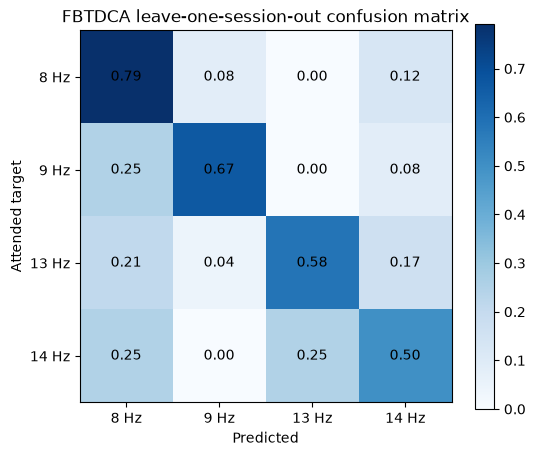

In [9]:
matrix = np.asarray(validation["normalized_confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, cmap="Blues")
labels = [f"{value:g} Hz" for value in dataset.candidate_frequencies_hz]
ax.set(xticks=range(4), yticks=range(4), xticklabels=labels, yticklabels=labels,
       xlabel="Predicted", ylabel="Attended target",
       title="FBTDCA leave-one-session-out confusion matrix")
for row in range(4):
    for column in range(4):
        ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax)
plt.show()

## Save the final estimator and reproducibility metadata

In [10]:
saved_model, saved_summary = save_fbtdca_model(
    dataset, estimator, validation, MODEL_PATH
)
print("Saved model:", saved_model)
print("Saved summary:", saved_summary)

Saved model: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\yehor_k\four_frequency_fbtdca.joblib
Saved summary: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\yehor_k\four_frequency_fbtdca_summary.json
